# 10주차: CNN 심화 — Data Augmentation, ResNet, Transfer Learning

## 이번 주 목표

지난주(9주차)에서 SimpleCNN으로 CIFAR-10을 학습했습니다.
- Train accuracy: **~93%**, Test accuracy: **~75%** → **18%p 차이** — 명백한 **overfitting**

이번 주에는 이 문제를 세 가지 방법으로 해결합니다:

| 기법 | 핵심 아이디어 |
|------|------|
| Data Augmentation | 이미지를 변형해서 학습 다양성 확보 → Overfitting 감소 |
| ResNet | Skip connection으로 더 깊은 네트워크 학습 가능 → 표현력 향상 |
| Transfer Learning | 이미 학습된 모델 재활용 → 적은 데이터로도 고성능 |

> **다음 주(11주차)**: 프로젝트 킥오프. 오늘 배운 기법들이 프로젝트의 핵심 도구가 됩니다!


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# GPU가 있으면 GPU, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


---
## Section 1: Data Augmentation

### 1-1 왜 필요한가?

9주차 SimpleCNN은 같은 훈련 이미지를 에포크마다 반복해서 봤습니다.
모델이 훈련 데이터를 **암기(memorization)** 하면 새로운 이미지에 일반화하지 못합니다.

**핵심 아이디어**: 고양이 사진을 좌우로 뒤집어도 여전히 고양이입니다.
이미지를 변형해서 학습하면 모델은 변형에 강인(robust)한 특징을 학습합니다.

> 실제 데이터를 늘리는 것이 아니라, **매 에포크마다 다른 변형**을 적용합니다.

### 1-2 주요 Augmentation 기법

| 기법 | 코드 | 설명 |
|------|------|------|
| RandomHorizontalFlip | `transforms.RandomHorizontalFlip()` | 50% 확률로 좌우 반전 |
| RandomCrop | `transforms.RandomCrop(32, padding=4)` | 패딩 후 랜덤 잘라내기 |
| ColorJitter | `transforms.ColorJitter(...)` | 밝기/대비/채도 랜덤 조절 |
| RandomRotation | `transforms.RandomRotation(15)` | ±15도 랜덤 회전 |

**핵심 규칙**: Augmentation은 **훈련 데이터에만** 적용합니다.
테스트 데이터에는 `Normalize`만 적용해야 공정한 평가가 됩니다.


100%|██████████| 170M/170M [00:03<00:00, 45.7MB/s] 


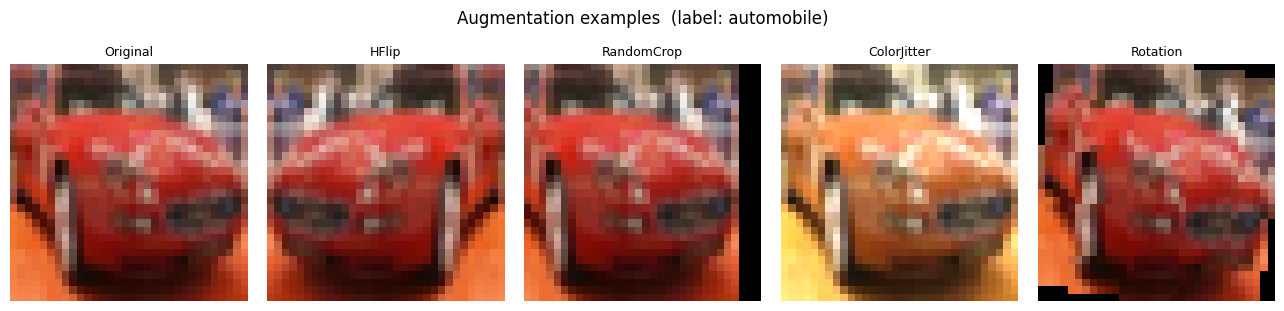

In [2]:
# CIFAR-10 전체 훈련 데이터에서 미리 계산된 채널별 평균·표준편차
# 정규화에 사용: (픽셀값 - mean) / std → 분포를 0 중심으로 맞춤
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Load one sample WITHOUT augmentation for visualization
_base_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                         transform=transforms.ToTensor())  #0~1사이로 변환해서 읽고
sample_img, sample_label = _base_ds[5]  #인덱스 5번 하나를 가져옴
sample_pil = transforms.ToPILImage()(sample_img) #다시 PIL로 변환. (PIL: Python Imaging Library)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

aug_list = {
    'Original':       transforms.Compose([transforms.ToTensor()]),
    'HFlip':          transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor()]),  #대칭변환 후 tensor로
    'RandomCrop':     transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.ToTensor()]),
    'ColorJitter':    transforms.Compose([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1), transforms.ToTensor()]),
    'Rotation':       transforms.Compose([transforms.RandomRotation(15), transforms.ToTensor()]),
}

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, (name, t) in zip(axes, aug_list.items()):
    ax.imshow(t(sample_pil).permute(1, 2, 0).numpy())   #imshow()는 다음 둘다 처리 가능 [0, 255] 정수 or [0.0, 1.0] 실수
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.suptitle(f'Augmentation examples  (label: {CLASSES[sample_label]})', y=1.02)
plt.tight_layout()
plt.show()


In [3]:
# 훈련용 transform: Augmentation + 정규화
# Augmentation은 훈련 데이터에만 적용 — 테스트에는 절대 적용하지 않음
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 50% 확률로
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  #0.8~1.2배 사이 랜덤
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# 테스트용 transform: 정규화만 적용
# Augmentation 없이 정규화만 해야 공정한 평가가 가능
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform_test)

# shuffle=True: 매 에포크마다 데이터 순서를 섞어 학습 다양성 확보
# pin_memory=True: GPU 전송 속도 향상 (CUDA 사용 시 효과적). pinned memory(페이지 고정 메모리)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
# 테스트는 shuffle 불필요 — 순서가 결과에 영향 없음
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset):,} | Test: {len(test_dataset):,}")


Train: 50,000 | Test: 10,000


---
## Section 2: Residual Networks (ResNet)

### 2-1 Degradation Problem

직관적으로 층이 깊을수록 성능이 좋아야 합니다.
하지만 실제로는 **일정 깊이를 넘으면 오히려 성능이 떨어지는** 현상이 관찰됐습니다 — **Degradation Problem**.

이것은 Vanishing Gradient와 다른 문제입니다. Batch Normalization으로도 해결이 어렵습니다.

**핵심 관찰**: 만약 추가된 층들이 **항등함수(identity)** 를 학습할 수 있다면,
더 깊은 네트워크는 최소한 얕은 네트워크만큼은 성능이 나와야 합니다.
그런데 실제로는 그렇지 않습니다 → 깊은 네트워크가 항등함수를 학습하기가 **어렵다**는 뜻입니다.

### 2-2 Skip Connection 아이디어

He et al. (2015)의 해결책: **층이 잔차(residual)를 학습하게 만들어라.**

기존 방식 — 목표 함수를 직접 학습:

$$H(x) = \mathcal{F}(x)$$

ResNet 방식 — 잔차를 학습하고, 입력을 그대로 더함:

$$H(x) = \mathcal{F}(x) + x$$

$x$를 그대로 더하는 연결을 **Skip Connection** 또는 **Shortcut Connection**이라 합니다.

**왜 더 쉬운가?**
항등함수가 최적이라면 $\mathcal{F}(x) = 0$만 학습하면 됩니다.
0을 학습하는 것이 복잡한 함수를 처음부터 학습하는 것보다 훨씬 쉽습니다.

**부가 효과**: Gradient가 skip connection을 통해 앞쪽 층까지 직접 흐릅니다 → Vanishing Gradient 완화


In [ ]:
#@title Residual Block 구조
from IPython.display import HTML
HTML("""<svg width="100%" viewBox="0 0 680 530" xmlns="http://www.w3.org/2000/svg">
<defs>
<marker id="arr" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
  <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
</marker>
<style>
.lbl{font-family:sans-serif;font-size:14px;font-weight:600;fill:#1a1a1a}
.sub{font-family:sans-serif;font-size:12px;fill:#555}
.bp{fill:#EDE9FC;stroke:#534AB7}.tp{fill:#26215C}
.bt{fill:#D4F0E7;stroke:#0F6E56}.tt{fill:#04342C}
.bb{fill:#D6EAFA;stroke:#185FA5}.tb{fill:#042C53}
.bc{fill:#FAECE7;stroke:#993C1D}.tc{fill:#4A1B0C}
</style>
</defs>
<text class="lbl" x="310" y="28" text-anchor="middle">Input x</text>
<line x1="310" y1="33" x2="310" y2="56" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<circle cx="310" cy="58" r="5" fill="#888" opacity="0.7"/>
<rect class="bp" x="215" y="65" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tp" x="310" y="86" text-anchor="middle" dominant-baseline="central">Conv2d</text>
<line x1="310" y1="107" x2="310" y2="120" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<rect class="bt" x="215" y="122" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tt" x="310" y="143" text-anchor="middle" dominant-baseline="central">BatchNorm2d</text>
<line x1="310" y1="164" x2="310" y2="177" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<rect class="bb" x="215" y="179" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tb" x="310" y="200" text-anchor="middle" dominant-baseline="central">ReLU</text>
<line x1="310" y1="221" x2="310" y2="234" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<rect class="bp" x="215" y="236" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tp" x="310" y="257" text-anchor="middle" dominant-baseline="central">Conv2d</text>
<line x1="310" y1="278" x2="310" y2="291" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<rect class="bt" x="215" y="293" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tt" x="310" y="314" text-anchor="middle" dominant-baseline="central">BatchNorm2d</text>
<line x1="310" y1="335" x2="310" y2="352" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<circle class="bc" cx="310" cy="374" r="24" stroke-width="0.5"/>
<text class="lbl tc" x="310" y="374" text-anchor="middle" dominant-baseline="central" font-size="20">+</text>
<line x1="310" y1="398" x2="310" y2="414" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<rect class="bb" x="215" y="416" width="190" height="42" rx="7" stroke-width="0.5"/>
<text class="lbl tb" x="310" y="437" text-anchor="middle" dominant-baseline="central">ReLU</text>
<line x1="310" y1="458" x2="310" y2="472" stroke="#888" stroke-width="1.5" marker-end="url(#arr)"/>
<text class="lbl" x="310" y="492" text-anchor="middle">Output</text>
<text class="sub" x="310" y="510" text-anchor="middle">H(x) = F(x) + x</text>
<path d="M 405 58 H 490 V 374 H 334" fill="none" stroke="#BA7517" stroke-width="2" marker-end="url(#arr)"/>
<text class="sub" x="500" y="148" text-anchor="start" fill="#BA7517">skip connection</text>
<text class="sub" x="500" y="163" text-anchor="start" fill="#BA7517">(x 그대로 전달)</text>
<text class="sub" x="200" y="200" text-anchor="end" fill="#888">F(x)</text>
<path d="M 210 107 Q 203 200 210 328" fill="none" stroke="#bbb" stroke-width="0.8"/>
<rect class="bp" x="30" y="413" width="12" height="12" rx="2" stroke-width="0.5"/>
<text class="sub" x="48" y="423">Conv2d</text>
<rect class="bt" x="30" y="433" width="12" height="12" rx="2" stroke-width="0.5"/>
<text class="sub" x="48" y="443">BatchNorm2d</text>
<rect class="bb" x="30" y="453" width="12" height="12" rx="2" stroke-width="0.5"/>
<text class="sub" x="48" y="463">ReLU</text>
<circle class="bc" cx="36" cy="481" r="6" stroke-width="0.5"/>
<text class="sub" x="48" y="485">덧셈 (+)</text>
</svg>""")

In [5]:
class ResidualBlock(nn.Module):
    """Basic Residual Block (same spatial size in/out)."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x                              # save input for skip connection

        out = F.relu(self.bn1(self.conv1(x)))     # Conv -> BN -> ReLU
        out = self.bn2(self.conv2(out))           # Conv -> BN  (no ReLU yet!)

        out = out + residual                      # skip connection: H(x) = F(x) + x
        out = F.relu(out)                         # ReLU after addition
        return out

# Shape check: channels and spatial size should be preserved
blk = ResidualBlock(64)
x_test = torch.randn(2, 64, 16, 16)
print(f"Input:  {x_test.shape}")
print(f"Output: {blk(x_test).shape}")   # (2, 64, 16, 16)


Input:  torch.Size([2, 64, 16, 16])
Output: torch.Size([2, 64, 16, 16])


### 2-3 Projection Shortcut (채널 수가 달라질 때)

채널 수를 늘리거나(64→128) 공간 크기를 줄일 때(stride=2)는
$x$와 $\mathcal{F}(x)$의 차원이 달라서 바로 더할 수 없습니다.

이 경우 **1×1 Conv**로 차원을 맞춥니다:

$$H(x) = \mathcal{F}(x) + W_s x$$

$W_s$는 1×1 Conv + BN으로 구성된 **projection shortcut**입니다.


In [6]:
#@title 1×1 Conv: 채널 방향 선형 결합
from IPython.display import HTML
HTML("""<svg width="100%" viewBox="0 0 680 440" xmlns="http://www.w3.org/2000/svg">
<defs>
<marker id="arr3" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="5" markerHeight="5" orient="auto-start-reverse"><path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/></marker>
<style>
.lbl{font-family:sans-serif;font-size:14px;font-weight:600;fill:#1a1a1a}
.sub{font-family:sans-serif;font-size:12px;fill:#555}
.bt{fill:#D4F0E7;stroke:#0F6E56}.tt{fill:#04342C}
.bc{fill:#FAECE7;stroke:#993C1D}.tc{fill:#4A1B0C}
.bg{fill:#F1EFE8;stroke:#888780}.tg{fill:#2C2C2A}
</style>
</defs>

<rect x="40" y="20" width="600" height="310" rx="12" fill="none" stroke="#1D9E75" stroke-width="1" stroke-dasharray="6 4" opacity="0.6"/>
<text class="lbl" x="340" y="14" text-anchor="middle" fill="#0F6E56">고정된 위치 (h, w) 에서의 연산</text>

<rect class="bt" x="60" y="40"  width="110" height="34" rx="6" stroke-width="0.5"/><text class="lbl tt" x="115" y="57"  text-anchor="middle" dominant-baseline="central">c₁</text>
<rect class="bt" x="60" y="84"  width="110" height="34" rx="6" stroke-width="0.5"/><text class="lbl tt" x="115" y="101" text-anchor="middle" dominant-baseline="central">c₂</text>
<rect class="bt" x="60" y="128" width="110" height="34" rx="6" stroke-width="0.5"/><text class="lbl tt" x="115" y="145" text-anchor="middle" dominant-baseline="central">c₃</text>
<rect class="bt" x="60" y="172" width="110" height="34" rx="6" stroke-width="0.5"/><text class="lbl tt" x="115" y="189" text-anchor="middle" dominant-baseline="central">c₄</text>
<text class="sub" x="115" y="222" text-anchor="middle">⋮</text>
<rect class="bt" x="60" y="232" width="110" height="34" rx="6" stroke-width="0.5" opacity="0.4"/><text class="lbl tt" x="115" y="249" text-anchor="middle" dominant-baseline="central" opacity="0.4">c₃₂</text>
<text class="sub" x="115" y="290" text-anchor="middle">입력 32채널</text>
<text class="sub" x="115" y="304" text-anchor="middle">at (h, w)</text>

<rect x="238" y="60" width="184" height="190" rx="8" fill="#FAEEDA" stroke="#EF9F27" stroke-width="0.8"/>
<text class="lbl" x="330" y="82" text-anchor="middle" fill="#412402">W</text>
<text class="sub" x="330" y="98" text-anchor="middle" fill="#854F0B">(64 × 32 행렬)</text>
<text class="sub" x="254" y="122" fill="#854F0B">w₁₁  w₁₂  ···  w₁,₃₂</text>
<text class="sub" x="254" y="142" fill="#854F0B">w₂₁  w₂₂  ···  w₂,₃₂</text>
<text class="sub" x="254" y="162" fill="#854F0B"> ⋮     ⋮           ⋮</text>
<text class="sub" x="254" y="182" fill="#854F0B">w₆₄,₁  ···   w₆₄,₃₂</text>
<text class="sub" x="330" y="222" text-anchor="middle" fill="#633806">모든 위치에서 공유</text>

<line x1="170" y1="57"  x2="238" y2="130" stroke="#EF9F27" stroke-width="2.5" opacity="0.8"/>
<line x1="170" y1="101" x2="238" y2="140" stroke="#EF9F27" stroke-width="1.3" opacity="0.5"/>
<line x1="170" y1="145" x2="238" y2="150" stroke="#EF9F27" stroke-width="3.2" opacity="1.0"/>
<line x1="170" y1="189" x2="238" y2="160" stroke="#EF9F27" stroke-width="0.7" opacity="0.3"/>
<line x1="170" y1="249" x2="238" y2="178" stroke="#EF9F27" stroke-width="0.5" opacity="0.2" stroke-dasharray="3 3"/>

<rect class="bc" x="510" y="52"  width="110" height="34" rx="6" stroke-width="0.8"/><text class="lbl tc" x="565" y="69"  text-anchor="middle" dominant-baseline="central">o₁</text>
<rect class="bc" x="510" y="96"  width="110" height="34" rx="6" stroke-width="0.5" opacity="0.6"/><text class="lbl tc" x="565" y="113" text-anchor="middle" dominant-baseline="central" opacity="0.6">o₂</text>
<text class="sub" x="565" y="148" text-anchor="middle">⋮</text>
<rect class="bc" x="510" y="158" width="110" height="34" rx="6" stroke-width="0.5" opacity="0.25"/><text class="lbl tc" x="565" y="175" text-anchor="middle" dominant-baseline="central" opacity="0.25">o₆₄</text>
<text class="sub" x="565" y="220" text-anchor="middle">출력 64채널</text>
<text class="sub" x="565" y="234" text-anchor="middle">at (h, w)</text>

<line x1="422" y1="130" x2="510" y2="69"  stroke="#993C1D" stroke-width="1.5" opacity="0.7" marker-end="url(#arr3)"/>
<line x1="422" y1="150" x2="510" y2="113" stroke="#993C1D" stroke-width="1.2" opacity="0.55" marker-end="url(#arr3)"/>
<line x1="422" y1="170" x2="510" y2="175" stroke="#993C1D" stroke-width="0.8" opacity="0.35" marker-end="url(#arr3)"/>

<rect class="bg" x="40" y="335" width="600" height="50" rx="8"/>
<text class="lbl tg" x="340" y="353" text-anchor="middle">공간 크기(H×W)는 변하지 않음</text>
<text class="sub" x="340" y="373" text-anchor="middle" fill="#5F5E5A">각 (h,w) 위치마다 독립적으로 같은 W를 적용 → 32채널→64채널 변환이 H×W번 반복됨</text>

<rect x="40" y="395" width="600" height="34" rx="8" fill="#FAEEDA" stroke="#EF9F27" stroke-width="0.5"/>
<text class="lbl" x="340" y="408" text-anchor="middle" fill="#412402">o₁ = w₁₁·c₁ + w₁₂·c₂ + ··· + w₁,₃₂·c₃₂</text>
<text class="sub" x="340" y="423" text-anchor="middle" fill="#854F0B">입력 32채널 전체의 가중합 → 출력 채널 하나</text>
</svg>""")

In [7]:
class DownsampleBlock(nn.Module):
    """Residual block that halves spatial size and doubles channels."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # Projection shortcut: 채널 수와 공간 크기를 맞추기 위한 1×1 Conv
        # - kernel_size=1: 채널 수만 변환, 공간 정보 보존
        # - stride=2: 공간 크기를 절반으로 줄임 (main path와 동일하게)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)              # projection shortcut으로 차원 맞춰서 더함
        return F.relu(out)


class CIFARResNet(nn.Module):
    """
    Small ResNet for CIFAR-10 (32x32 input).
    32x32 -> stem(32ch) -> ResBlock -> Down(64ch,16x16) -> ResBlock
           -> Down(128ch,8x8) -> ResBlock -> AvgPool -> FC(10)
    """
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.layer1 = ResidualBlock(32)           # 32x32
        self.layer2 = DownsampleBlock(32, 64)     # 32x32 -> 16x16
        self.layer3 = ResidualBlock(64)           # 16x16
        self.layer4 = DownsampleBlock(64, 128)    # 16x16 -> 8x8
        self.layer5 = ResidualBlock(128)          # 8x8
        # AdaptiveAvgPool2d(1): 공간 크기를 1×1로 줄임 → 채널별 평균값 하나씩
        self.avgpool = nn.AdaptiveAvgPool2d(1)   # 8x8 → 1x1
        self.fc      = nn.Linear(128, 10)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)                # (batch, 128, 1, 1) → (batch, 128) 펼치기
        return self.fc(x)

model_resnet = CIFARResNet().to(device)
total_params = sum(p.numel() for p in model_resnet.parameters())
print(f"CIFARResNet total parameters: {total_params:,}")

# Sanity check
dummy = torch.randn(4, 3, 32, 32).to(device)
print(f"Output shape: {model_resnet(dummy).shape}")   # (4, 10)


CIFARResNet total parameters: 678,058
Output shape: torch.Size([4, 10])


In [8]:
# ─── Training utilities ───────────────────────────────────────────
# ── 한 에포크 학습 함수 ──────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()                                    # BN/Dropout을 훈련 모드로 전환
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()                            # 이전 배치의 gradient 초기화
        outputs = model(images)                          # forward pass
        loss = criterion(outputs, labels)                # loss 계산
        loss.backward()                                  # backward pass: gradient 계산
        optimizer.step()                                 # 파라미터 업데이트
        total_loss += loss.item() * images.size(0)       # 배치 loss 누적
        correct    += (outputs.argmax(1) == labels).sum().item()  # 정답 수 누적
        total      += images.size(0)
    return total_loss / total, correct / total           # 에포크 평균 loss, accuracy

# ── 평가 함수 (gradient 계산 없음) ──────────────────────────────
@torch.no_grad()  # 평가 시에는 gradient 불필요 → 메모리·속도 절약
def evaluate(model, loader, criterion):
    model.eval()                                     # BN/Dropout을 평가 모드로 전환
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

criterion = nn.CrossEntropyLoss()


In [9]:
# CIFARResNet 학습 (Augmentation 적용 데이터)
EPOCHS = 15
optimizer_res = optim.Adam(model_resnet.parameters(), lr=1e-3)
# CosineAnnealingLR: lr을 코사인 곡선으로 서서히 줄임 → 후반부 미세 조정 효과
scheduler_res = optim.lr_scheduler.CosineAnnealingLR(optimizer_res, T_max=EPOCHS)

history_res = {'train_acc': [], 'test_acc': []}

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model_resnet, train_loader, optimizer_res, criterion)
    te_loss, te_acc = evaluate(model_resnet, test_loader, criterion)
    scheduler_res.step()

    history_res['train_acc'].append(tr_acc)
    history_res['test_acc'].append(te_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  Train: {tr_acc:.3f}  Test: {te_acc:.3f}")

print(f"\nCIFARResNet Final Test Acc: {history_res['test_acc'][-1]:.3f}")


Epoch [ 5/15]  Train: 0.795  Test: 0.802
Epoch [10/15]  Train: 0.873  Test: 0.849
Epoch [15/15]  Train: 0.910  Test: 0.879

CIFARResNet Final Test Acc: 0.879


---
## Section 3: Transfer Learning

### 3-1 개념

ImageNet으로 학습된 ResNet18은 **1,281,167장** 이미지로 훈련됐습니다.
CIFAR-10의 훈련 데이터는 **50,000장**입니다.

ImageNet 학습 과정에서 모델은 이미 다음을 학습했습니다:

| 층 깊이 | 학습된 특징 |
|---------|---------|
| 초기 층 | 엣지, 코너, 색상 그래디언트 (저수준) |
| 중간 층 | 텍스처, 패턴, 부품 (중간 수준) |
| 후반 층 | 눈, 코, 바퀴, 날개 (고수준, task-specific) |

초기~중간 층의 특징은 **다른 이미지 분류 과제에도 재활용 가능**합니다.

> 처음부터 학습하지 말고, 이미 잘 학습된 표현을 재활용합시다.

### 3-2 두 가지 전략

| 전략 | 방법 | 언제 사용? |
|------|------|------|
| **Feature Extraction** | Backbone freeze, classifier만 학습 | 데이터 적을 때, 빠른 학습 |
| **Fine-tuning** | Backbone 일부 또는 전체도 함께 학습 | 데이터 충분, 더 높은 성능 원할 때 |

**Fine-tuning 학습률 주의사항**:
- Backbone: **매우 작은 lr** (e.g. `1e-4`) — 이미 잘 학습된 가중치를 망가뜨리지 않기 위해
- Classifier: **상대적으로 큰 lr** (e.g. `1e-3`) — 새 과제에 빠르게 적응하기 위해


In [10]:
#@title ResNet18 전체 구조
from IPython.display import HTML
HTML("""<svg width="100%" viewBox="0 0 680 570" xmlns="http://www.w3.org/2000/svg">
<defs>
<marker id="ar" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="5" markerHeight="5" orient="auto-start-reverse">
  <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
</marker>
<style>
.lbl{font-family:sans-serif;font-size:14px;font-weight:600;fill:#1a1a1a}
.sub{font-family:sans-serif;font-size:11px;fill:#555}
.bp{fill:#EDE9FC;stroke:#534AB7}.tp{fill:#26215C}
.bt{fill:#D4F0E7;stroke:#0F6E56}.tt{fill:#04342C}
.bb{fill:#D6EAFA;stroke:#185FA5}.tb{fill:#042C53}
.ba{fill:#FAEEDA;stroke:#EF9F27}.ta{fill:#412402}
.bc{fill:#FAECE7;stroke:#993C1D}.tc{fill:#4A1B0C}
.bg{fill:#F1EFE8;stroke:#888780}.tg{fill:#2C2C2A}
</style>
</defs>

<text class="lbl" x="340" y="20" text-anchor="middle">ResNet18 전체 구조</text>

<rect class="bg" x="230" y="28" width="220" height="38" rx="7" stroke-width="0.5"/>
<text class="lbl tg" x="340" y="44" text-anchor="middle" dominant-baseline="central">입력 이미지</text>
<text class="sub" x="340" y="59" text-anchor="middle">3 × 32 × 32 (CIFAR-10)</text>

<line x1="340" y1="66" x2="340" y2="78" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect x="60" y="78" width="560" height="88" rx="10" fill="none" stroke="#534AB7" stroke-width="1" stroke-dasharray="5 4" opacity="0.5"/>
<text class="lbl" x="80" y="96" fill="#26215C">Stem</text>

<rect class="bc" x="80" y="100" width="120" height="40" rx="6" stroke-width="1"/>
<text class="lbl tc" x="140" y="116" text-anchor="middle" dominant-baseline="central">conv1</text>
<text class="sub" x="140" y="130" text-anchor="middle" fill="#993C1D">kernel 7→3, stride 2→1</text>
<text class="sub" x="140" y="150" text-anchor="middle" fill="#993C1D">← 수정</text>

<line x1="200" y1="120" x2="216" y2="120" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bp" x="218" y="100" width="120" height="40" rx="6" stroke-width="0.5"/>
<text class="lbl tp" x="278" y="120" text-anchor="middle" dominant-baseline="central">BN + ReLU</text>

<line x1="338" y1="120" x2="354" y2="120" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bc" x="356" y="100" width="120" height="40" rx="6" stroke-width="1"/>
<text class="lbl tc" x="416" y="116" text-anchor="middle" dominant-baseline="central">maxpool</text>
<text class="sub" x="416" y="130" text-anchor="middle" fill="#993C1D">stride=2 → Identity()</text>
<text class="sub" x="416" y="150" text-anchor="middle" fill="#993C1D">← 수정</text>

<text class="sub" x="548" y="118" text-anchor="middle">출력</text>
<text class="sub" x="548" y="132" text-anchor="middle">32×32</text>

<line x1="340" y1="166" x2="340" y2="178" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bp" x="60" y="178" width="560" height="54" rx="8" stroke-width="0.5"/>
<text class="lbl tp" x="80" y="198" dominant-baseline="central">layer1</text>
<text class="sub" x="80" y="216">64채널 · 32×32 유지</text>
<text class="lbl tp" x="596" y="198" text-anchor="end" dominant-baseline="central">2 × BasicBlock</text>
<text class="sub" x="596" y="216" text-anchor="end">Conv→BN→ReLU→Conv→BN + skip</text>

<line x1="340" y1="232" x2="340" y2="244" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bt" x="60" y="244" width="560" height="54" rx="8" stroke-width="0.5"/>
<text class="lbl tt" x="80" y="264" dominant-baseline="central">layer2</text>
<text class="sub" x="80" y="282">64→128채널 · 32×32→16×16</text>
<text class="lbl tt" x="596" y="264" text-anchor="end" dominant-baseline="central">2 × BasicBlock</text>
<text class="sub" x="596" y="282" text-anchor="end">첫 번째: stride=2, projection shortcut</text>

<line x1="340" y1="298" x2="340" y2="310" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bb" x="60" y="310" width="560" height="54" rx="8" stroke-width="0.5"/>
<text class="lbl tb" x="80" y="330" dominant-baseline="central">layer3</text>
<text class="sub" x="80" y="348">128→256채널 · 16×16→8×8</text>
<text class="lbl tb" x="596" y="330" text-anchor="end" dominant-baseline="central">2 × BasicBlock</text>
<text class="sub" x="596" y="348" text-anchor="end">첫 번째: stride=2, projection shortcut</text>

<line x1="340" y1="364" x2="340" y2="376" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="ba" x="60" y="376" width="560" height="54" rx="8" stroke-width="0.5"/>
<text class="lbl ta" x="80" y="396" dominant-baseline="central">layer4</text>
<text class="sub" x="80" y="414">256→512채널 · 8×8→4×4</text>
<text class="lbl ta" x="596" y="396" text-anchor="end" dominant-baseline="central">2 × BasicBlock</text>
<text class="sub" x="596" y="414" text-anchor="end">첫 번째: stride=2, projection shortcut</text>

<line x1="340" y1="430" x2="340" y2="442" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bg" x="200" y="442" width="280" height="38" rx="7" stroke-width="0.5"/>
<text class="lbl tg" x="340" y="458" text-anchor="middle" dominant-baseline="central">avgpool</text>
<text class="sub" x="340" y="473" text-anchor="middle">AdaptiveAvgPool2d · 4×4 → 1×1</text>

<line x1="340" y1="480" x2="340" y2="492" stroke="#888" stroke-width="1.5" marker-end="url(#ar)"/>

<rect class="bc" x="200" y="492" width="280" height="38" rx="7" stroke-width="1"/>
<text class="lbl tc" x="340" y="508" text-anchor="middle" dominant-baseline="central">fc  Linear(512 → 10)</text>
<text class="sub" x="340" y="522" text-anchor="middle" fill="#993C1D">1000 → 10으로 교체  ← 수정</text>

<rect x="60" y="546" width="560" height="18" rx="5" fill="none" stroke="#993C1D" stroke-width="0.5" opacity="0.5"/>
<text class="sub" x="340" y="559" text-anchor="middle" fill="#993C1D">수정 항목: conv1 (kernel 7→3, stride 2→1)  ·  maxpool → Identity()  ·  fc (1000→10)</text>
</svg>""")

In [11]:
# ResNet18 전체 구조 확인
import torchvision.models as models

model_preview = models.resnet18(weights=None)   # 구조 확인용 — 가중치 불필요

# 레이어별 파라미터 수와 함께 출력
print("=" * 55)
print("ResNet18 전체 구조")
print("=" * 55)
for name, module in model_preview.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:<12} {str(module.__class__.__name__):<25} params: {params:,}")
    # layer1~4는 내부 블록 구성도 표시
    if name.startswith("layer"):
        for i, block in enumerate(module):
            print(f"    [{i}] BasicBlock")
            for bname, bmod in block.named_children():
                print(f"        {bname:<12} {str(bmod)}")
print("=" * 55)

# CIFAR-10용으로 바꿀 부분 표시
print("\n[CIFAR-10 적용 시 수정할 레이어]")
print(f"  conv1   원래: {model_preview.conv1}  →  kernel=3, stride=1로 교체")
print(f"  maxpool 원래: {model_preview.maxpool}  →  nn.Identity()로 교체")
print(f"  fc      원래: {model_preview.fc}  →  Linear(512, 10)으로 교체")

ResNet18 전체 구조
  conv1        Conv2d                    params: 9,408
  bn1          BatchNorm2d               params: 128
  relu         ReLU                      params: 0
  maxpool      MaxPool2d                 params: 0
  layer1       Sequential                params: 147,968
    [0] BasicBlock
        conv1        Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        bn1          BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        relu         ReLU(inplace=True)
        conv2        Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        bn2          BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    [1] BasicBlock
        conv1        Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        bn1          BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        relu         ReLU(inplace=True)


### 3-3 CIFAR-10 적용 시 주의사항

ResNet18은 **224×224** 입력용으로 설계됐습니다. CIFAR-10은 **32×32**이므로 수정이 필요합니다.

| 레이어 | 원래 설정 | CIFAR-10용 수정 | 이유 |
|--------|-----------|-----------------|------|
| conv1 | kernel=7, stride=2 → 112×112 | kernel=3, stride=1 → 32×32 유지 | 너무 작아지면 정보 손실 |
| maxpool | stride=2 → 56×56 | `nn.Identity()` (제거) | 32×32에서는 불필요한 다운샘플링 |
| fc | Linear(512, 1000) | Linear(512, 10) | 10개 클래스로 교체 |


In [12]:
# Transfer Learning 모델 준비 함수
def make_cifar_resnet18(freeze_backbone=True):
    """사전학습된 ResNet18을 CIFAR-10(32×32) 입력에 맞게 수정한다."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # 32×32 입력 적응:
    # - conv1: kernel=7,stride=2 → kernel=3,stride=1 (원래대로면 출력이 너무 작아짐)
    # - maxpool: nn.Identity()로 교체 → 불필요한 다운샘플링 제거
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  #새로 만든 레이어는 항상 requires_grad=True
    model.maxpool = nn.Identity()  #maxpool 아무 것도 안하도록

    if freeze_backbone:
        # 모든 파라미터를 먼저 freeze
        for param in model.parameters():
            param.requires_grad = False #새로 만든 conv1 레이어 포함 requires_grad=False

    # 분류기 교체 (새로 만든 레이어는 자동으로 requires_grad=True)
    model.fc = nn.Linear(512, 10)

    # conv1과 layer1은 반드시 학습되어야 함:
    # - conv1: 랜덤 초기화된 새 레이어 → 사전학습 가중치 없음
    # - layer1: conv1 출력 분포가 바뀌었으므로 함께 적응 필요
    for param in model.conv1.parameters():
        param.requires_grad = True  #새로 만든 conv1 레이어는 다시 requires_grad = True
    for param in model.layer1.parameters():
        param.requires_grad = True

    return model


model_ft = make_cifar_resnet18(freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_ft.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.2f}%)")

# Sanity check
with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32).to(device)
    print(f"Output shape: {model_ft(dummy).shape}")   # (4, 10)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Trainable: 154,826 / 11,173,962  (1.39%)
Output shape: torch.Size([4, 10])


In [13]:
# Feature Extraction 학습
# requires_grad=True인 파라미터만 optimizer에 전달 (conv1, layer1, fc)
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=1e-3)
# StepLR: 5 에포크마다 lr을 절반으로 줄임
scheduler_ft  = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.5)

# CIFARResNet과 동일한 epoch 수로 공정하게 비교
EPOCHS_FT = 15
history_ft = {'train_acc': [], 'test_acc': []}

for epoch in range(EPOCHS_FT):
    tr_loss, tr_acc = train_one_epoch(model_ft, train_loader, optimizer_ft, criterion)
    te_loss, te_acc = evaluate(model_ft, test_loader, criterion)
    scheduler_ft.step()

    history_ft['train_acc'].append(tr_acc)
    history_ft['test_acc'].append(te_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS_FT}]  Train: {tr_acc:.3f}  Test: {te_acc:.3f}")

print(f"\nFeature Extraction Final Test Acc: {history_ft['test_acc'][-1]:.3f}")


Epoch [ 5/15]  Train: 0.841  Test: 0.856
Epoch [10/15]  Train: 0.878  Test: 0.882
Epoch [15/15]  Train: 0.893  Test: 0.894

Feature Extraction Final Test Acc: 0.894


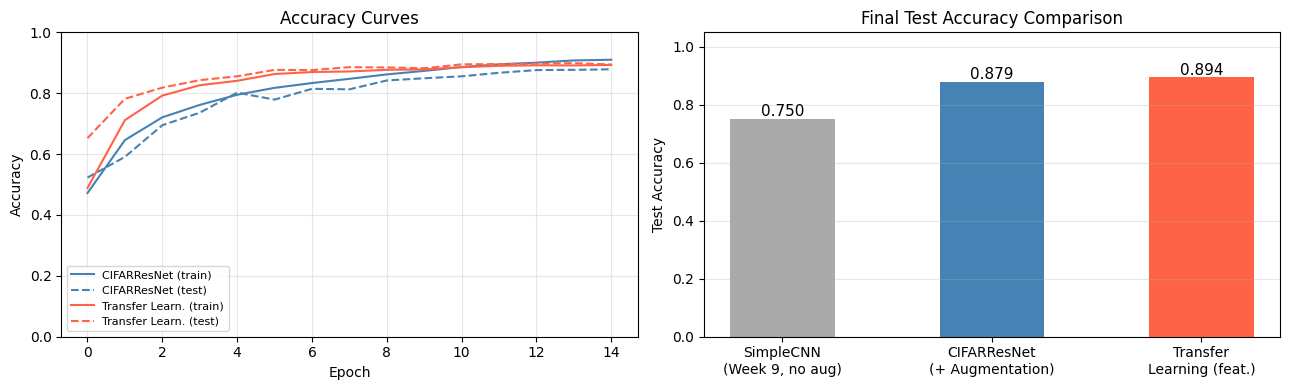

In [14]:
# Comparison: SimpleCNN (Week 9) vs CIFARResNet vs Transfer Learning
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: accuracy curves
ax = axes[0]
ax.plot(history_res['train_acc'], color='steelblue',  label='CIFARResNet (train)')
ax.plot(history_res['test_acc'],  color='steelblue',  linestyle='--', label='CIFARResNet (test)')
ax.plot(history_ft['train_acc'],  color='tomato',     label='Transfer Learn. (train)')
ax.plot(history_ft['test_acc'],   color='tomato',     linestyle='--', label='Transfer Learn. (test)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy'); ax.set_title('Accuracy Curves')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)

# Right: final test accuracy bar chart
ax2 = axes[1]
labels_bar = ['SimpleCNN\n(Week 9, no aug)', 'CIFARResNet\n(+ Augmentation)', 'Transfer\nLearning (feat.)']
test_accs  = [0.75, history_res['test_acc'][-1], history_ft['test_acc'][-1]]
colors_bar = ['#aaaaaa', 'steelblue', 'tomato']
bars = ax2.bar(labels_bar, test_accs, color=colors_bar, width=0.5)
for bar, v in zip(bars, test_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('Test Accuracy')
ax2.set_title('Final Test Accuracy Comparison')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


---
## 정리

| 기법 | 핵심 아이디어 | 코드 키워드 |
|------|------|------|
| Data Augmentation | 변형된 이미지로 다양성 확보 | `RandomHorizontalFlip`, `RandomCrop` |
| Residual Block | skip connection으로 잔차 학습 | `out = out + residual` |
| Transfer Learning | 사전학습 특징 재활용 | `weights=..., requires_grad=False` |

Residual Block의 핵심 수식:

$$H(x) = \mathcal{F}(x) + x$$

**핵심 포인트**:
1. Augmentation은 훈련 데이터에만 — 테스트에는 Normalize만
2. Skip connection: ReLU **이전에** 더한다 (`BN → +residual → ReLU`)
3. 채널/크기가 달라지면 1×1 Conv projection shortcut
4. CIFAR-10(32×32): conv1 kernel 3, maxpool 제거

### 다음 주 (11주차: 프로젝트 킥오프)

오늘 배운 코드를 그대로 가져다 쓸 수 있습니다.
- 어떤 모델로 시작할까? SimpleCNN? CIFARResNet? Transfer Learning?
- 데이터셋에 맞는 Augmentation 전략은?
- Baseline 구현 및 실험 계획 수립


---
# Part 2: 실습 (100분)

> 영상을 보고 왔다면 충분히 풀 수 있는 수준입니다. 막히면 Part 1 코드를 먼저 확인하세요.

**수업 시간 배분 가이드**:
- A1~A5 (Augmentation + ResidualBlock): 25분
- A6~A10 (Transfer Learning): 30분
- 라이브 풀이: 20분
- B파트 안내 + 시작: 15분


In [15]:
# [A-1] Augmentation — add random horizontal flip to transform_train.

transform_train_A1 = transforms.Compose([
    ______,                                   # random horizontal flip (50%)
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])
print("A1:", transform_train_A1)


NameError: name '______' is not defined

In [ ]:
# [A-2] For RandomCrop(32, padding=4) on a 32x32 image:
# compute the padded size and the final cropped size.

padded_size  = ______    # after padding (e.g. padding=4 on 32x32)
cropped_size = ______    # after RandomCrop(32)

print(f"Padded: {padded_size}x{padded_size}  →  Cropped: {cropped_size}x{cropped_size}")


In [ ]:
# [A-3] ResidualBlock — add the skip connection.

class ResidualBlock_A3(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = ______                          # add skip connection
        return F.relu(out)

blk = ResidualBlock_A3(64)
x = torch.randn(2, 64, 16, 16)
print("A3:", blk(x).shape)   # expect (2, 64, 16, 16)


In [ ]:
# [A-4] Compute the output shape after passing through ResidualBlock.

block = ResidualBlock(64)
x = torch.randn(8, 64, 32, 32)    # batch=8, C=64, H=W=32

out = block(x)
# expected shape: ______
print("A4:", out.shape)
assert out.shape == ______         # fill in as a tuple, e.g. (8, 64, 32, 32)


In [ ]:
# [A-5] Fill in the kernel_size for the projection shortcut in DownsampleBlock.

class DownsampleBlock_A5(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=______, stride=2, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))

dsb = DownsampleBlock_A5(32, 64)
x = torch.randn(2, 32, 32, 32)
print("A5:", dsb(x).shape)   # expect (2, 64, 16, 16)


In [ ]:
# [A-6] Load pretrained ResNet18 using the modern weights= API.

model_a6 = models.resnet18(weights=______)    # pretrained ImageNet weights
print("fc:", model_a6.fc)    # should print Linear(512, 1000)


In [ ]:
# [A-7] Freeze all parameters of the backbone.

model_a7 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_a7.______():              # iterate over all parameters
    param.requires_grad = ______            # freeze

trainable = sum(p.numel() for p in model_a7.parameters() if p.requires_grad)
print(f"Trainable after freeze: {trainable:,}")   # should be 0


In [ ]:
# [A-8] Adapt ResNet18's conv1 and maxpool for 32x32 input.

model_a8 = make_cifar_resnet18(freeze_backbone=True).to(device)

# original conv1: kernel=7, stride=2 (designed for 224x224)
# CIFAR-10 adaptation:
model_a8.conv1  = nn.Conv2d(3, 64, kernel_size=______, stride=1, padding=1, bias=False)
model_a8.maxpool = ______                   # remove aggressive downsampling

with torch.no_grad():
    out = model_a8(torch.randn(2, 3, 32, 32).to(device))
print("A8:", out.shape)   # expect (2, 10)


In [ ]:
# [A-9] Pass only trainable parameters (requires_grad=True) to the optimizer.

model_a9 = make_cifar_resnet18(freeze_backbone=True).to(device)

optimizer_a9 = optim.Adam(
    filter(lambda p: ______, model_a9.parameters()),   # trainable only
    lr=1e-3
)

trainable = sum(p.numel() for p in model_a9.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")   # 512*10 + 10 = 5,130


In [ ]:
# [A-10] Complete the function that returns total and trainable parameter counts.

def count_params(model):
    total     = sum(p.numel() for p in model.______())
    trainable = sum(p.numel() for p in model.______() if p.requires_grad)
    return total, trainable

total_r, train_r = count_params(model_resnet)   # CIFARResNet
total_t, train_t = count_params(model_ft)       # Transfer Learning

print(f"CIFARResNet     — Total: {total_r:>9,} | Trainable: {train_r:>9,}")
print(f"TransferLearning — Total: {total_t:>9,} | Trainable: {train_t:>9,}")


In [ ]:
# =====================================================================
# [B] Fine-tuning Pipeline 구현  (숙제 가능)
# =====================================================================
# Feature Extraction보다 한 단계 더 나아가,
# Backbone 일부를 "unfreeze"하여 함께 학습하는 2단계 Fine-tuning을 구현합니다.
#
# 전략:
#   Stage 1 (5 epochs) : fc layer만 학습 — backbone freeze
#   Stage 2 (15 epochs): layer4 + fc 학습 — backbone 일부 unfreeze
#
# 힌트:
#   - named_parameters() 로 레이어 이름 확인 가능
#   - param.requires_grad = True/False 로 제어
#   - optimizer param_groups 로 레이어별 다른 lr 적용
# =====================================================================

model_b = make_cifar_resnet18(freeze_backbone=True).to(device)

# ── Stage 1: train fc only ───────────────────────────────────────
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, model_b.parameters()),
    lr=______                                  # stage 1 lr
)

hist_s1 = {'train_acc': [], 'test_acc': []}
for epoch in range(5):
    tr_loss, tr_acc = train_one_epoch(model_b, train_loader, optimizer_s1, criterion)
    te_loss, te_acc = evaluate(model_b, test_loader, criterion)
    hist_s1['train_acc'].append(tr_acc)
    hist_s1['test_acc'].append(te_acc)
    print(f"[S1] Ep {epoch+1}/5  Train: {tr_acc:.3f}  Test: {te_acc:.3f}")

# ── Stage 2: unfreeze layer4 ────────────────────────────────────
for name, param in model_b.______():          # named_parameters()
    if 'layer4' in name:
        param.requires_grad = ______          # unfreeze

optimizer_s2 = optim.Adam([
    {'params': [p for n, p in model_b.named_parameters()
                if 'layer4' in n and p.requires_grad], 'lr': ______},  # backbone lr
    {'params': model_b.fc.parameters(),                 'lr': ______},  # classifier lr
])

hist_s2 = {'train_acc': [], 'test_acc': []}
for epoch in range(15):
    tr_loss, tr_acc = train_one_epoch(model_b, train_loader, optimizer_s2, criterion)
    te_loss, te_acc = evaluate(model_b, test_loader, criterion)
    hist_s2['train_acc'].append(tr_acc)
    hist_s2['test_acc'].append(te_acc)
    if (epoch + 1) % 5 == 0:
        print(f"[S2] Ep {epoch+1}/15  Train: {tr_acc:.3f}  Test: {te_acc:.3f}")

# ── result visualization ────────────────────────────────────────
all_train = hist_s1['train_acc'] + hist_s2['train_acc']
all_test  = hist_s1['test_acc']  + hist_s2['test_acc']

plt.figure(figsize=(8, 4))
plt.plot(all_train, label='Train', color='steelblue')
plt.plot(all_test,  label='Test',  color='tomato')
plt.axvline(5, color='gray', linestyle='--', label='Stage 2: unfreeze layer4')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Fine-tuning: Stage 1 (freeze) → Stage 2 (unfreeze layer4)')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"\nFinal Fine-tuning Test Acc: {all_test[-1]:.3f}")


---
## ✅ 체크리스트

- [ ] Augmentation은 **훈련 데이터에만** 적용했다
- [ ] `RandomCrop(32, padding=4)` — 40×40으로 패딩 후 32×32를 잘라냄을 이해했다
- [ ] `out = out + residual` — BN 뒤, ReLU 앞에 skip connection이 들어감을 확인했다
- [ ] 채널/크기가 달라지면 **1×1 Conv projection shortcut**이 필요함을 이해했다
- [ ] `requires_grad = False` 로 backbone을 freeze하는 방법을 안다
- [ ] Feature Extraction과 Fine-tuning의 차이를 설명할 수 있다

## 💭 생각해볼 질문

1. `out = out + residual` 대신 `out = out * residual`로 바꾸면 어떤 문제가 생길까요?
   (힌트: gradient가 어떻게 흐를지 생각해보세요)

2. 오늘 사용한 `RandomHorizontalFlip`이 CIFAR-10의 **어떤 클래스**에는 부적절할 수 있을까요?
   이유는 무엇인가요?

3. ImageNet 사전학습 모델을 **의료 영상(X-ray)** 분류에 쓴다면 유용할까요?
   초기 층과 후반 층 중 어느 쪽을 더 많이 바꿔야 할까요? 이유는?
